<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/05_FUNt_Geometric_Ledger_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNt Geometric Ledger v1.0
## C8 Geometric Regime Dynamics and Recursive Strain

Generated as part of the FUNt Transition Laboratory notebook suite.

## Archive Path Clarity

This notebook prints the current working directory and the absolute archive path so saved run artifacts are easy to locate in Colab, Jupyter, or local storage.


In [1]:
# --------------------- ARCHIVE PATH CLARITY HELPER ---------------------

from pathlib import Path
import os
import json
from datetime import datetime, timezone

def show_working_paths(archive_folder="funt_transition_laboratory_archive"):
    cwd = Path.cwd()
    archive = Path(archive_folder)
    archive.mkdir(parents=True, exist_ok=True)

    print("Current working directory:")
    print(cwd.resolve())

    print("\nArchive folder:")
    print(archive.resolve())

    existing = list(archive.glob("*"))
    print(f"\nExisting archive items: {len(existing)}")
    for item in existing[:20]:
        print(" -", item.resolve())
    if len(existing) > 20:
        print(" ...")

    return archive.resolve()

def save_run_artifact(run_record, archive_folder="funt_transition_laboratory_archive", prefix="run"):
    """
    Save a run artifact as JSON and print the full absolute path.
    """
    archive = Path(archive_folder)
    archive.mkdir(parents=True, exist_ok=True)

    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    cfg_hash = run_record.get("config_hash", "nohash")
    out = archive / f"{prefix}_{ts}_{cfg_hash}.json"

    with open(out, "w", encoding="utf-8") as f:
        json.dump(run_record, f, indent=2, default=str)

    print("\nArchive saved to:")
    print(out.resolve())
    return out.resolve()

ARCHIVE_PATH = show_working_paths()


Current working directory:
/content

Archive folder:
/content/funt_transition_laboratory_archive

Existing archive items: 0


## Purpose

Implements geometric regime dynamics.

Each regime is described as a geometric configuration with:

- attractor proximity,
- strain,
- coherence,
- phase,
- effective scaling,
- log-scale visibility.

In [2]:
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UTC_NOW = datetime.now(timezone.utc)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

VERSION = "FUNt Geometric Ledger v1.0"
print(VERSION)


FUNt Geometric Ledger v1.0


,n,ratio,error_vs_phi,phase_deg,phase_error_deg
0,2,2.000000,0.381966,0.000000,222.492236
1,3,1.500000,0.118034,180.000000,42.492236
2,4,1.666667,0.048633,240.000000,17.507764
3,5,1.600000,0.018034,216.000000,6.492236
4,6,1.625000,0.006966,225.000000,2.507764
5,7,1.615385,0.002649,221.538462,0.953774
6,8,1.619048,0.001014,222.857143,0.364907
7,9,1.617647,0.000387,222.352941,0.139295
8,10,1.618182,0.000148,222.545455,0.053219
9,11,1.617978,0.000056,222.471910,0.020326


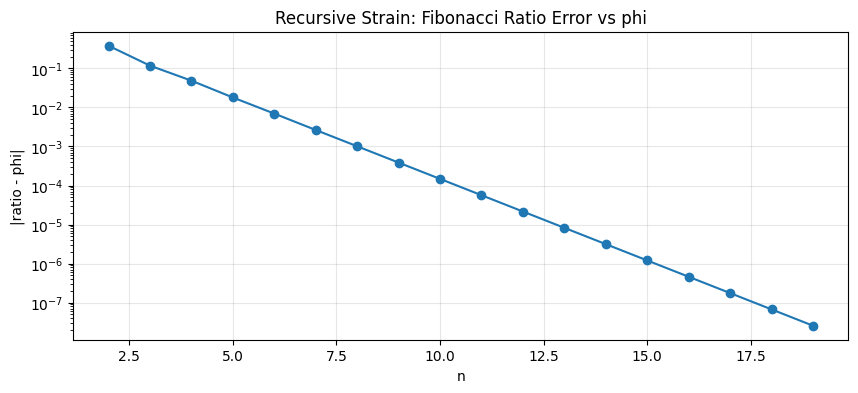

In [3]:
def fibonacci_ratios(n=20):
    F = [0, 1]
    for _ in range(2, n+2):
        F.append(F[-1] + F[-2])
    rows = []
    phi = (1 + np.sqrt(5))/2
    for k in range(2, n):
        ratio = F[k+1]/F[k]
        error = abs(ratio - phi)
        phase = (ratio * 360) % 360
        phase_phi = (phi * 360) % 360
        rows.append({
            "n": k,
            "ratio": ratio,
            "error_vs_phi": error,
            "phase_deg": phase,
            "phase_error_deg": abs(phase - phase_phi),
        })
    return pd.DataFrame(rows)

fib = fibonacci_ratios(20)
display(fib.head(10))

plt.figure(figsize=(10,4))
plt.semilogy(fib["n"], fib["error_vs_phi"], marker="o")
plt.title("Recursive Strain: Fibonacci Ratio Error vs phi")
plt.xlabel("n")
plt.ylabel("|ratio - phi|")
plt.grid(True, alpha=0.3)
plt.show()
